# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402127
- 姓名：郭嘉祺
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-jiaqiguo111
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析报告

## 1. 摘要

报告基于 `ershoufang_list.csv` 福州二手房挂牌数据，围绕“房源供给集中在哪里、价格差异如何形成、主流产品结构是什么、哪些板块具有明显溢价”四个问题展开分析。报告使用 pandas 和 NumPy 完成数据读取、缺失值与重复值检查、描述性统计、分组聚合和相关性分析，并从 `面积`、`总价`、`均价`、`户型`、`楼层`、`时间`、`所属区域` 等原始文本字段中提取结构化变量，构造出面积段、总价段、户型类别、区域圈层和板块等分析字段。在可视化部分，报告通过区域供给强度与价格溢价矩阵、均价分布图、面积—总价趋势图、户型气泡矩阵、总价结构堆叠图、高价板块排名和房龄价格差异图，综合分析福州二手房市场的空间分化和产品结构。

分析结果显示，福州二手房样本共包含 11856 条房源记录，其中价格有效样本为 11830 条。样本房源面积中位数为 93㎡，总价中位数为 173 万元，均价中位数为 18325.5 元/㎡。从区域看，福州二手房市场并不是简单的“房源越多价格越高”，而是呈现出更复杂的分层结构：鼓楼表现为低供给但高溢价，晋安表现为高供给且高溢价，仓山则表现为高供给但价格相对平稳。主城区均价中位数为 19293 元/㎡，明显高于外围区县的 12297 元/㎡，说明区域区位和资源配置对价格具有持续影响。从产品结构看，3室房源和60—120㎡房源构成市场主力；面积与总价相关性较强，但面积与均价相关性较弱，说明面积主要影响总价，而均价更多受到区域、板块和房源品质影响。板块层面进一步显示，高价房源主要集中在鼓楼、台江、晋安和仓山等主城区核心板块，说明福州二手房价格差异不仅存在于市区之间，也体现在同一市区内部的板块分化上。

## 2. 数据来源与分析目标

本报告使用数据文件 `ershoufang_list.csv`，其数据主题为福州二手房房源信息分析。数据集中每一行代表一条二手房挂牌房源记录，字段包括房源编号、城市、市区、标题、户型、面积、方位、楼层、建造时间、所属小区、所属区域、房源链接、总价、均价和房龄等信息。

本报告的主要分析目标是基于福州二手房挂牌数据，了解福州二手房市场的房源供给结构、区域价格差异和影响房价的主要因素。具体包括：分析不同市区的房源数量分布，比较不同区域的总价和均价水平，观察户型、面积、房龄、楼层等因素与房价之间的关系，并识别数据中可能存在的高价房源或异常房源。

在分析方法上，本文将结合课程中学习的 NumPy、pandas 和数据可视化方法完成数据处理与分析。首先使用 pandas 读取和理解数据，然后检查缺失值、重复值和异常值；接着从原始文本字段中提取面积、价格、户型、楼层和建造年份等结构化变量；最后通过分组聚合、描述性统计和可视化图表，对福州二手房市场特征进行分析，并得出有数据支持的结论。

## 3. 数据读取与基本理解


### 3.1 导入分析库

In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

本报告主要使用 NumPy 进行数值计算，使用 pandas 完成数据读取、数据清洗、分组聚合和描述性统计，并使用 Matplotlib、Seaborn 进行后续可视化分析。

### 3.2 读取数据并查看前几行

In [220]:
df = pd.read_csv('ershoufang_list.csv')
df.head(3).T

,0,1,2
id,1,2,3
城市,fuzhou,fuzhou,fuzhou
市区,台江,晋安,晋安
标题,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟
户型,3 室 2 厅 2 卫,3 室 2 厅 2 卫,3 室 2 厅 1 卫
面积,103㎡,83㎡,90㎡
面积数值,103.0,83.0,90.0
方位,南北,南北,南北
楼层,中层(共31层),低层(共18层),高层(共33层)
时间,2025年建造,2025年建造,2024年建造


通过查看数据前几行可以发现，每条记录对应一条福州二手房挂牌房源。数据中既包含市区、户型、面积、朝向、楼层、建造时间、小区和所属区域等房屋属性信息，也包含总价、均价等价格信息。部分字段以文本形式存储，并带有单位或混合格式，例如“面积”“总价”“均价”“楼层”“户型”等，后续需要进一步清洗和提取。

### 3.3 查看数据规模

In [221]:
print("数据行数和列数：", df.shape)

数据行数和列数： (11856, 18)


数据集共有 11856 条房源记录，包含 18 个字段，样本量较为充足，可以支持后续从市区、户型、面积、房龄和楼层等多个维度进行统计分析。

### 3.4 查看字段名称和数据类型

In [222]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  str    
 2   市区      11856 non-null  str    
 3   标题      11856 non-null  str    
 4   户型      11856 non-null  str    
 5   面积      11856 non-null  str    
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  str    
 8   楼层      11856 non-null  str    
 9   时间      11856 non-null  str    
 10  所属小区    11856 non-null  str    
 11  所属区域    11856 non-null  str    
 12  房源链接    11856 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  str    
dtypes: float64(3), int64(1), str(14)
memory usage: 1.6 MB


In [223]:
df.columns

Index(['id', '城市', '市区', '标题', '户型', '面积', '面积数值', '方位', '楼层', '时间', '所属小区',
       '所属区域', '房源链接', '总价', '总价数值', '均价', '均价数值', '房龄'],
      dtype='str')

从字段类型可以看出，数据集中共有 18 个字段，其中 `id` 为整数型，`面积数值`、`总价数值`、`均价数值` 为浮点型，其余 14 个字段为字符串类型。虽然数据中已经提供了部分数值字段，但 `面积`、`总价`、`均价`、`户型`、`楼层`、`时间` 等原始字段仍包含单位、空格或组合信息，因此后续仍需要从原始文本字段中重新提取可分析变量，以体现数据清洗过程的完整性。

### 3.5 字段含义说明

| 字段 | 含义 | 后续用途 |
|---|---|---|
| `id` | 房源编号 | 判断房源是否重复 |
| `城市` | 城市名称 | 确认数据来源城市 |
| `市区` | 房源所在市区 | 区域分布与区域价格对比 |
| `标题` | 房源标题 | 辅助理解房源特征 |
| `户型` | 房屋户型 | 提取室、厅、卫数量 |
| `面积` | 房屋面积文本 | 提取面积数值 |
| `面积数值` | 已整理的面积数值 | 与提取结果进行校验 |
| `方位` | 房屋朝向 | 构造朝向相关备选特征 |
| `楼层` | 楼层信息 | 提取楼层位置和总楼层 |
| `时间` | 建造时间 | 提取建造年份 |
| `所属小区` | 小区名称 | 小区维度分析 |
| `所属区域` | 具体区域信息 | 提取板块信息 |
| `房源链接` | 房源网页链接 | 判断房源是否重复 |
| `总价` | 总价文本 | 提取总价数值 |
| `总价数值` | 已整理的总价数值 | 与提取结果进行校验 |
| `均价` | 均价文本 | 提取单位面积价格 |
| `均价数值` | 已整理的均价值 | 与提取结果进行校验 |
| `房龄` | 房龄分类 | 分析不同房龄房源价格差异 |

## 4. 数据质量检查

在正式分析之前，本文从缺失值、重复值、字段唯一值、异常值和类别分布等方面对数据质量进行检查，以判断数据是否适合后续统计分析，并为数据清洗和特征构造提供依据。

### 4.1 缺失值检查

In [224]:
missing_count = df.isnull().sum()
missing_rate = df.isnull().mean()

missing_table = pd.DataFrame({
    '缺失值数量': missing_count,
    '缺失比例': missing_rate
})

missing_table

,缺失值数量,缺失比例
id,0,0.000000
城市,0,0.000000
市区,0,0.000000
标题,0,0.000000
户型,0,0.000000
面积,0,0.000000
面积数值,0,0.000000
方位,0,0.000000
楼层,0,0.000000
时间,0,0.000000


缺失值检查结果显示，数据集中大部分字段不存在缺失，整体完整性较好。仅价格相关字段存在缺失，其中 `总价`、`总价数值`、`均价`、`均价数值` 均缺失 26 条，缺失比例约为 0.22%。

由于价格字段是后续房价分析的核心变量，涉及总价和均价的分析时需要剔除这些缺失记录；但在分析房源数量、区域分布和户型结构时，这些记录仍可保留。

### 4.2 重复值检查

In [225]:
print("整行重复记录数量：", df.duplicated().sum())
print("id 重复数量：", df['id'].duplicated().sum())
print("房源链接重复数量：", df['房源链接'].duplicated().sum())

整行重复记录数量： 0
id 重复数量： 0
房源链接重复数量： 0


重复值检查结果显示，整行重复记录数量为 0，`id` 重复数量为 0，`房源链接` 重复数量为 0。说明数据中不存在明显的重复房源记录，样本唯一性较好，可以保留原始记录进行后续分析。

### 4.3 字段唯一值检查

In [226]:
df.nunique().sort_values(ascending=False)

id      11856
房源链接    11856
标题       9788
均价       6656
均价数值     6656
面积数值     3405
面积       3405
所属小区     1577
所属区域     1540
总价数值      800
总价        800
楼层        139
户型         56
时间         39
市区         12
方位         10
房龄          4
城市          1
dtype: int64

从字段唯一值数量来看，`id` 和 `房源链接` 均有 11856 个唯一值，进一步说明每条记录基本对应一套独立房源。`城市` 只有 1 个取值，说明数据集中房源均来自福州。

用于分组分析的字段中，`市区` 有 12 个类别，`房龄` 有 4 个类别，`户型` 有 56 个类别，适合进一步进行区域、房龄和户型维度的对比分析。同时，`所属小区` 和 `所属区域` 的唯一值数量较多，后续可作为更细粒度的板块或小区分析依据。

### 4.4 异常值初步检查

In [227]:
df[['面积数值', '总价数值', '均价数值']].describe()

,面积数值,总价数值,均价数值
count,11856.000000,11830.000000,11830.00000
mean,97.888336,190.761657,19235.60093
std,25.924588,111.174039,6925.94972
min,18.000000,16.800000,2169.00000
25%,84.730000,130.000000,15298.25000
50%,93.000000,173.000000,18325.50000
75%,113.010000,225.000000,22268.50000
max,500.000000,3180.000000,92968.00000


从数值字段的描述性统计结果看，面积、总价和均价均存在一定极端值。房源面积最大值为 500㎡，总价最大值为 3180 万元，均价最大值为 92968 元/㎡，均明显高于普通房源水平。这类记录可能对应别墅、大平层或核心地段高端房源。

考虑到极端值可能拉高均值，本文后续在进行区域、户型和面积段价格比较时，将更多使用中位数作为主要参考指标。同时，这些高价房源本身也反映了市场中的高端供给特征，因此本文不直接删除，而是在后续分析中结合具体场景判断。

### 4.5 类别字段分布检查

In [228]:
display(df['市区'].value_counts().to_frame('房源数量'))
display(df['房龄'].value_counts().to_frame('房源数量'))
display(df['户型'].value_counts().head(20).to_frame('房源数量'))

,房源数量
市区,
晋安,4350
仓山,3948
鼓楼,1239
台江,906
闽侯,630
福清,219
连江,176
马尾,169
长乐,106


,房源数量
房龄,
10年以上,3055
2-5年,3052
5-10年,3049
2年内,2700


,房源数量
户型,
3 室 2 厅 2 卫,4964
4 室 2 厅 2 卫,2005
3 室 2 厅 1 卫,1724
2 室 2 厅 1 卫,1142
2 室 1 厅 1 卫,703
3 室 1 厅 1 卫,318
1 室 1 厅 1 卫,286
4 室 2 厅 3 卫,236
3 室 1 厅 2 卫,128


从类别字段分布看，房源在区域上具有明显集中性。晋安和仓山房源数量最多，分别为 4350 条和 3948 条，明显高于其他市区，说明样本中的二手房挂牌主要集中在这两个区域。

从房龄分布看，`10年以上`、`2-5年`、`5-10年` 三类房源数量接近，`2年内` 房源数量略少，说明样本覆盖了不同新旧程度的房源。户型方面，`3室2厅2卫` 数量最多，其次为 `4室2厅2卫` 和 `3室2厅1卫`，说明样本中的主流房源以家庭居住型户型为主。

## 5. 数据清洗与特征构造

本部分从原始文本字段开始进行数据清洗。首先对 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型`、`方位`、`所属区域` 等文本字段进行格式整理，处理首尾空格、换行符等问题；然后通过正则表达式从带单位或混合格式的字段中提取可分析的数值变量和分类变量。通过这些处理，可以将原始文本信息转换为适合分组统计和可视化分析的结构化字段。

### 5.1 文本字段预处理

In [229]:
df_clean = df.copy()

# 去除文本字段中的首尾空格、换行符等
text_cols = ['面积', '总价', '均价', '时间', '楼层', '户型', '方位', '所属区域']

for col in text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype('string')
        .str.strip()
        .str.replace('\n', '', regex=False)
        .str.replace('\r', '', regex=False)
    )

df_clean[text_cols].head()

,面积,总价,均价,时间,楼层,户型,方位,所属区域
0,103㎡,199万,19321元/㎡,2025年建造,中层(共31层),3 室 2 厅 2 卫,南北,台江 万宝 交通西路
1,83㎡,181万,21808元/㎡,2025年建造,低层(共18层),3 室 2 厅 2 卫,南北,晋安 五四北 坂中路
2,90㎡,159万,17667元/㎡,2024年建造,高层(共33层),3 室 2 厅 1 卫,南北,晋安 福马路 七贤路2号
3,90㎡,300万,33334元/㎡,2025年建造,低层(共7层),3 室 2 厅 1 卫,南北,鼓楼 东街 湖头街
4,107㎡,330万,30842元/㎡,2024年建造,低层(共18层),3 室 2 厅 2 卫,南北,晋安 王庄 连洋西路


### 5.2 面积、总价和均价提取

In [230]:
# 从原始文本字段中提取面积、总价和均价
df_clean['面积_㎡'] = df_clean['面积'].astype('string').str.extract(r'(\d+\.?\d*)')[0].astype(float)
df_clean['总价_万元'] = df_clean['总价'].astype('string').str.extract(r'(\d+\.?\d*)')[0].astype(float)
df_clean['均价_元每平'] = df_clean['均价'].astype('string').str.extract(r'(\d+\.?\d*)')[0].astype(float)

df_clean[['面积', '面积_㎡', '总价', '总价_万元', '均价', '均价_元每平']].head(10)

,面积,面积_㎡,总价,总价_万元,均价,均价_元每平
0,103㎡,103.0,199万,199.0,19321元/㎡,19321.0
1,83㎡,83.0,181万,181.0,21808元/㎡,21808.0
2,90㎡,90.0,159万,159.0,17667元/㎡,17667.0
3,90㎡,90.0,300万,300.0,33334元/㎡,33334.0
4,107㎡,107.0,330万,330.0,30842元/㎡,30842.0
5,89㎡,89.0,193万,193.0,21686元/㎡,21686.0
6,62㎡,62.0,196万,196.0,31613元/㎡,31613.0
7,99㎡,99.0,299万,299.0,30203元/㎡,30203.0
8,75㎡,75.0,160万,160.0,21334元/㎡,21334.0
9,69㎡,69.0,145万,145.0,21015元/㎡,21015.0


从结果可以看出，`面积`、`总价`、`均价` 原本是带有单位的文本字段。通过正则表达式提取数字后，分别生成了 `面积_㎡`、`总价_万元` 和 `均价_元每平` 三个数值型字段，为后续统计分析和可视化提供基础。

### 5.3 数值提取结果校验

In [231]:
# 检查重新提取的数值是否与原有数值列一致
print("面积提取是否一致：", np.allclose(df_clean['面积_㎡'], df_clean['面积数值'], equal_nan=True))
print("总价提取是否一致：", np.allclose(df_clean['总价_万元'], df_clean['总价数值'], equal_nan=True))
print("均价提取是否一致：", np.allclose(df_clean['均价_元每平'], df_clean['均价数值'], equal_nan=True))

面积提取是否一致： True
总价提取是否一致： True
均价提取是否一致： True


通过与数据集中已有的数值列进行对比，可以验证文本提取结果是否可靠。三个结果均为 True，说明从原始字段中提取出的面积、总价和均价值与已有数值列一致，后续分析可以使用重新命名后的字段。

### 5.4 户型变量拆分

In [232]:
# 从户型字段中提取室、厅、卫数量
df_clean['室'] = df_clean['户型'].str.extract(r'(\d+)\s*室').astype(float)
df_clean['厅'] = df_clean['户型'].str.extract(r'(\d+)\s*厅').astype(float)
df_clean['卫'] = df_clean['户型'].str.extract(r'(\d+)\s*卫').astype(float)

df_clean[['户型', '室', '厅', '卫']].head(10)

,户型,室,厅,卫
0,3 室 2 厅 2 卫,3.0,2.0,2.0
1,3 室 2 厅 2 卫,3.0,2.0,2.0
2,3 室 2 厅 1 卫,3.0,2.0,1.0
3,3 室 2 厅 1 卫,3.0,2.0,1.0
4,3 室 2 厅 2 卫,3.0,2.0,2.0
5,3 室 2 厅 2 卫,3.0,2.0,2.0
6,2 室 1 厅 1 卫,2.0,1.0,1.0
7,3 室 2 厅 2 卫,3.0,2.0,2.0
8,2 室 2 厅 1 卫,2.0,2.0,1.0
9,2 室 1 厅 1 卫,2.0,1.0,1.0


`户型` 字段原本为“几室几厅几卫”的文本格式。通过提取其中的室、厅、卫数量，可以将户型信息拆分成多个数值变量，便于后续分析不同户型结构与房价之间的关系。

### 5.5 户型类别构造

In [233]:
# 根据“室”的数量构造户型类别
def classify_room(x):
    if pd.isna(x):
        return '未知'
    elif x == 1:
        return '1室'
    elif x == 2:
        return '2室'
    elif x == 3:
        return '3室'
    elif x == 4:
        return '4室'
    else:
        return '5室及以上'

df_clean['户型类别'] = df_clean['室'].apply(classify_room)

df_clean['户型类别'].value_counts()

户型类别
3室       7191
4室       2305
2室       1945
1室        303
5室及以上     112
Name: count, dtype: int64

由于原始户型类别较多，直接分析会比较分散，因此根据“室”的数量将户型归并为 `1室`、`2室`、`3室`、`4室` 和 `5室及以上`。这样既保留了户型差异，又便于进行分组统计和可视化比较。

### 5.6 楼层与建造年份提取

In [234]:
# 从楼层字段中提取楼层位置和总楼层数
df_clean['楼层位置'] = df_clean['楼层'].str.extract(r'(低层|中层|高层)')
df_clean['总楼层'] = df_clean['楼层'].str.extract(r'共(\d+)层').astype(float)

df_clean[['楼层', '楼层位置', '总楼层']].head(10)

,楼层,楼层位置,总楼层
0,中层(共31层),中层,31.0
1,低层(共18层),低层,18.0
2,高层(共33层),高层,33.0
3,低层(共7层),低层,7.0
4,低层(共18层),低层,18.0
5,高层(共18层),高层,18.0
6,低层(共16层),低层,16.0
7,低层(共18层),低层,18.0
8,低层(共34层),低层,34.0
9,中层(共27层),中层,27.0


`楼层` 字段原本同时包含楼层位置和总楼层数，例如“中层(共31层)”。本报告将其拆分为 `楼层位置` 和 `总楼层` 两个变量，作为后续扩展分析和辅助理解房源特征的备选字段。

In [235]:
# 从时间字段中提取建造年份
df_clean['建造年份'] = df_clean['时间'].str.extract(r'(\d{4})').astype(float)

# 使用数据中的最大建造年份作为参考年份，计算推算房龄
analysis_year = int(df_clean['建造年份'].max())
df_clean['推算房龄'] = analysis_year - df_clean['建造年份']

df_clean[['时间', '建造年份', '推算房龄', '房龄']].head(10)

,时间,建造年份,推算房龄,房龄
0,2025年建造,2025.0,1.0,2年内
1,2025年建造,2025.0,1.0,2年内
2,2024年建造,2024.0,2.0,2年内
3,2025年建造,2025.0,1.0,2年内
4,2024年建造,2024.0,2.0,2年内
5,2025年建造,2025.0,1.0,2年内
6,2024年建造,2024.0,2.0,2年内
7,2024年建造,2024.0,2.0,2年内
8,2024年建造,2024.0,2.0,2年内
9,2024年建造,2024.0,2.0,2年内


`时间` 字段包含房屋建造年份信息。通过正则表达式提取年份后，可以得到 `建造年份`，并进一步计算 `推算房龄`。数据中原有的 `房龄` 字段为分类变量，而 `推算房龄` 为连续数值变量，二者结合可以更细致地分析房屋新旧程度。

### 5.7 板块信息提取

In [236]:
# 拆分所属区域字段，提取板块信息
area_split = df_clean['所属区域'].str.split(r'\s+', n=2, expand=True)

df_clean['区域_市区'] = area_split[0]
df_clean['板块'] = area_split[1]
df_clean['具体位置'] = area_split[2]

df_clean[['所属区域', '区域_市区', '板块', '具体位置']].head(10)

,所属区域,区域_市区,板块,具体位置
0,台江 万宝 交通西路,台江,万宝,交通西路
1,晋安 五四北 坂中路,晋安,五四北,坂中路
2,晋安 福马路 七贤路2号,晋安,福马路,七贤路2号
3,鼓楼 东街 湖头街,鼓楼,东街,湖头街
4,晋安 王庄 连洋西路,晋安,王庄,连洋西路
5,晋安 五四北 坂中路,晋安,五四北,坂中路
6,鼓楼 东街 白马北路,鼓楼,东街,白马北路
7,晋安 前横路 鱼山路3号,晋安,前横路,鱼山路3号
8,台江 万宝 交通西路,台江,万宝,交通西路
9,台江 万宝 白马南路289号,台江,万宝,白马南路289号


`所属区域` 字段包含市区、板块和具体位置等信息。将其拆分后，可以得到更细粒度的 `板块` 变量。相比只分析市区，板块维度能够更具体地反映福州二手房市场的空间差异。

### 5.8 面积段、总价段与其他分类变量构造

In [237]:
# 构造面积段
area_bins = [0, 60, 90, 120, 144, 1000]
area_labels = ['60㎡以下', '60-90㎡', '90-120㎡', '120-144㎡', '144㎡以上']

df_clean['面积段'] = pd.cut(
    df_clean['面积_㎡'],
    bins=area_bins,
    labels=area_labels,
    right=False
)

# 构造总价段
price_bins = [0, 100, 150, 200, 300, 500, 5000]
price_labels = ['100万以下', '100-150万', '150-200万', '200-300万', '300-500万', '500万以上']

df_clean['总价段'] = pd.cut(
    df_clean['总价_万元'],
    bins=price_bins,
    labels=price_labels,
    right=False
)

display(df_clean['面积段'].value_counts().sort_index().to_frame('房源数量'))
display(df_clean['总价段'].value_counts().sort_index().to_frame('房源数量'))

,房源数量
面积段,
60㎡以下,466
60-90㎡,4594
90-120㎡,4762
120-144㎡,1694
144㎡以上,340


,房源数量
总价段,
100万以下,1064
100-150万,3199
150-200万,3540
200-300万,3018
300-500万,860
500万以上,149


为了便于分析房源产品结构，本文将连续的面积和总价变量进一步划分为区间型变量。`面积段` 可以反映市场中主流房源面积区间，`总价段` 可以反映不同购房预算下的房源供给情况。

In [238]:
# 构造区域圈层
main_districts = ['鼓楼', '台江', '仓山', '晋安']

df_clean['区域圈层'] = df_clean['市区'].apply(
    lambda x: '主城区' if x in main_districts else '外围区县'
)

# 判断是否含南向
df_clean['是否含南向'] = df_clean['方位'].apply(
    lambda x: '含南向' if '南' in str(x) else '不含南向'
)

display(df_clean['区域圈层'].value_counts().to_frame('房源数量'))
display(df_clean['是否含南向'].value_counts().to_frame('房源数量'))

,房源数量
区域圈层,
主城区,10443
外围区县,1413


,房源数量
是否含南向,
含南向,11451
不含南向,405


考虑到福州不同区域之间可能存在明显价格差异，本文将鼓楼、台江、仓山和晋安划分为主城区，其余地区划分为外围区县。同时，根据朝向字段构造 `是否含南向` 变量，作为后续扩展分析的备选特征。

### 5.9 价格分析数据集构造

In [239]:
# 涉及价格分析时，剔除总价或均价缺失的记录
df_price = df_clean.dropna(subset=['总价_万元', '均价_元每平']).copy()

print("清洗后完整数据规模：", df_clean.shape)
print("价格分析数据规模：", df_price.shape)
print("剔除价格缺失记录数：", df_clean.shape[0] - df_price.shape[0])

清洗后完整数据规模： (11856, 36)
价格分析数据规模： (11830, 36)
剔除价格缺失记录数： 26


由于总价和均价字段存在 26 条缺失记录，因此在进行价格相关分析时，本文使用剔除价格缺失值后的 `df_price` 数据集；在分析房源数量、市区分布、户型结构等不依赖价格的内容时，仍使用完整的 `df_clean` 数据集。

## 6. 描述性统计分析

在完成数据清洗和特征构造后，本部分将从整体价格水平、区域差异、户型结构、面积段分布和变量相关性等角度进行描述性统计分析。通过 pandas 的分组、聚合、排序和统计描述方法，初步了解福州二手房市场的基本特征，为后续可视化分析和结论归纳提供数据依据。

### 6.1 整体价格与面积统计

In [240]:
# 对面积、总价和均价进行整体描述性统计
overall_stats = df_price[['面积_㎡', '总价_万元', '均价_元每平']].describe().T

overall_stats

,count,mean,std,min,25%,50%,75%,max
面积_㎡,11830.0,97.843371,25.897159,18.0,84.5625,93.0,113.0,500.0
总价_万元,11830.0,190.761657,111.174039,16.8,130.0000,173.0,225.0,3180.0
均价_元每平,11830.0,19235.600930,6925.949720,2169.0,15298.2500,18325.5,22268.5,92968.0


从整体统计结果看，剔除价格缺失值后，价格分析数据共包含 11830 条有效房源记录。样本房源面积中位数为 93㎡，说明福州二手房以中等面积住宅为主；总价中位数为 173 万元，均价中位数为 18325.5 元/㎡，反映出样本中的主流房源价格水平。

同时，面积、总价和均价的最大值明显高于中位数，尤其是总价最高达到 3180 万元，均价最高达到 92968 元/㎡，说明数据中存在少量高端或核心地段房源。由于这些极端房源可能拉高均值，后续分析将更多使用中位数来比较不同类别房源的价格水平。

### 6.2 不同市区房源数量与价格水平

In [241]:
# 按市区统计房源数量、面积、总价和均价
district_stats = df_price.groupby('市区').agg(
    房源数量=('id', 'count'),
    面积中位数=('面积_㎡', 'median'),
    总价中位数=('总价_万元', 'median'),
    均价均值=('均价_元每平', 'mean'),
    均价中位数=('均价_元每平', 'median')
).sort_values('均价中位数', ascending=False)

district_stats.round(2)

,房源数量,面积中位数,总价中位数,均价均值,均价中位数
市区,,,,,
鼓楼,1239,90.00,195.0,25083.16,22973.0
晋安,4346,91.13,187.0,20524.36,20000.0
台江,906,89.73,175.0,21938.26,19763.5
仓山,3926,97.00,173.0,17979.35,17613.5
连江,176,107.00,147.5,13098.03,13445.0
马尾,169,101.00,128.0,13052.51,13072.0
闽侯,630,89.00,110.0,11698.95,12844.5
福清,219,118.15,138.0,12267.33,11819.0
长乐,106,105.00,126.0,12289.05,11736.5


从市区维度看，福州二手房样本呈现出明显的区域集中现象。晋安和仓山的房源数量分别为 4346 条和 3926 条，远高于其他区域，是样本中挂牌最活跃的两个市区。

从价格水平看，鼓楼的均价中位数最高，达到 22973 元/㎡，明显高于其他区域；晋安、台江和仓山也处于较高水平。相比之下，永泰和罗源的均价中位数明显偏低。整体来看，福州二手房价格具有明显的空间分化特征，中心城区价格水平普遍高于外围区县。

### 6.3 主城区与外围区县对比

In [242]:
# 按区域圈层统计房源数量和价格水平
circle_stats = df_price.groupby('区域圈层').agg(
    房源数量=('id', 'count'),
    面积中位数=('面积_㎡', 'median'),
    总价中位数=('总价_万元', 'median'),
    均价中位数=('均价_元每平', 'median'),
    均价均值=('均价_元每平', 'mean')
)

circle_stats.round(2)

,房源数量,面积中位数,总价中位数,均价中位数,均价均值
区域圈层,,,,,
主城区,10417,92.51,180.0,19293.0,20230.38
外围区县,1413,99.00,123.0,12297.0,11901.80


主城区与外围区县的对比进一步验证了福州二手房市场的区域分化。主城区房源数量为 10417 条，占据样本绝大多数，说明二手房挂牌主要集中在城市核心区域。

价格方面，主城区均价中位数为 19293 元/㎡，明显高于外围区县的 12297 元/㎡；主城区总价中位数也达到 180 万元，高于外围区县的 123 万元。由此可见，主城区不仅房源供给更集中，整体价格水平也更高，区位因素是影响福州二手房价格的重要因素。

### 6.4 不同户型类别的房源结构与价格

In [243]:
# 按户型类别统计房源数量、面积、总价和均价
room_order = ['1室', '2室', '3室', '4室', '5室及以上']

room_stats = df_price.groupby('户型类别').agg(
    房源数量=('id', 'count'),
    面积中位数=('面积_㎡', 'median'),
    总价中位数=('总价_万元', 'median'),
    均价中位数=('均价_元每平', 'median')
).reindex(room_order)

room_stats.round(2)

,房源数量,面积中位数,总价中位数,均价中位数
户型类别,,,,
1室,303,45.00,85.0,19556.0
2室,1945,73.01,131.0,18400.0
3室,7183,92.73,175.0,17768.0
4室,2288,124.00,240.0,20591.0
5室及以上,111,141.00,300.0,21203.0


从户型结构看，3室房源数量最多，共 7183 条，是福州二手房样本中的绝对主力户型；其次为4室和2室房源，说明市场供给主要面向家庭居住和改善型需求。

从价格表现看，随着居室数量增加，面积和总价整体上升。1室房源总价中位数为 85 万元，而4室和5室及以上房源分别达到 240 万元和 300 万元。值得注意的是，4室及以上房源的均价中位数也明显更高，说明大户型不仅面积更大，也可能更多分布在品质较高或区位较好的小区。

### 6.5 不同面积段的房源结构与价格

In [244]:
# 按面积段统计房源数量和价格水平
area_stats = df_price.groupby('面积段', observed=True).agg(
    房源数量=('id', 'count'),
    总价中位数=('总价_万元', 'median'),
    均价中位数=('均价_元每平', 'median')
)

area_stats.round(2)

,房源数量,总价中位数,均价中位数
面积段,,,
60㎡以下,466,80.0,17778.0
60-90㎡,4591,140.0,18106.0
90-120㎡,4745,188.0,18170.0
120-144㎡,1690,245.0,19210.0
144㎡以上,338,445.0,26048.5


从面积段统计结果看，福州二手房样本中的主力面积区间集中在中小面积和中等面积段，说明市场供给以刚需和普通改善型住宅为主。随着面积段提升，房源总价中位数整体上升，反映出面积仍然是影响总价的重要因素。

同时，不同面积段的均价并不完全呈线性变化，说明单位面积价格除了受面积影响外，还与区域位置、小区品质、房龄和配套条件等因素有关。

### 6.6 数值变量相关性分析

In [245]:
# 分析主要数值变量之间的相关关系
corr_cols = ['面积_㎡', '总价_万元', '均价_元每平', '室', '厅', '卫', '总楼层', '推算房龄']

corr_matrix = df_price[corr_cols].corr()

corr_matrix.round(3)

,面积_㎡,总价_万元,均价_元每平,室,厅,卫,总楼层,推算房龄
面积_㎡,1.000,0.643,0.143,0.770,0.434,0.655,-0.015,-0.028
总价_万元,0.643,1.000,0.786,0.452,0.205,0.405,-0.001,0.017
均价_元每平,0.143,0.786,1.000,0.082,-0.027,0.074,-0.012,0.095
室,0.770,0.452,0.082,1.000,0.472,0.635,-0.094,-0.093
厅,0.434,0.205,-0.027,0.472,1.000,0.402,-0.013,-0.048
卫,0.655,0.405,0.074,0.635,0.402,1.000,-0.053,-0.197
总楼层,-0.015,-0.001,-0.012,-0.094,-0.013,-0.053,1.000,-0.304
推算房龄,-0.028,0.017,0.095,-0.093,-0.048,-0.197,-0.304,1.000


相关性分析显示，面积与总价的相关系数为 0.643，说明房屋面积越大，总价通常越高，二者存在较明显的正相关关系。面积与“室”“卫”等户型变量也具有较高相关性，说明居室数量增加通常伴随着房屋面积扩大。

相比之下，面积与均价的相关系数仅为 0.143，相关性较弱，说明单位面积价格并不主要由面积决定。总价与均价的相关系数为 0.786，表明高总价房源往往也具有较高单价。整体来看，面积主要影响总价，而均价更可能受到区域位置、房屋品质和周边配套等因素影响。

## 7. 可视化分析

在前文描述性统计的基础上，本部分进一步通过可视化图表展示福州二手房市场的区域价格分化、面积与总价关系、户型价格梯度、产品结构和房龄差异。每张图表均围绕一个明确分析问题展开，以便更直观地解释统计结果。

In [246]:
from matplotlib.colors import LinearSegmentedColormap

colors = {
    "fog_pink": "#FCE8E6",      # 雾粉
    "coral_pink": "#FFC6BC",    # 珊瑚粉
    "light_pink": "#F8B9B8",    # 浅霞粉
    "cloud_blue": "#D6DFEF",    # 云灰蓝
    "ice_blue": "#A5CDE2",      # 冰蓝
    "lake_blue": "#5FA3CB",     # 湖蓝
    "sky_blue": "#668FCA",      # 天青
    "lavender": "#C9CEFE",      # 薰衣草
    "sea_blue": "#66A8CD",      # 海蓝
    "deep_blue": "#006BAD",     # 深海蓝
    "text": "#263238"
}

# 自定义连续型色带
blue_cmap = LinearSegmentedColormap.from_list(
    "blue_cmap",
    [colors["fog_pink"], colors["cloud_blue"], colors["ice_blue"], colors["lake_blue"], colors["deep_blue"]]
)

pink_blue_cmap = LinearSegmentedColormap.from_list(
    "pink_blue_cmap",
    [colors["fog_pink"], colors["coral_pink"], colors["ice_blue"], colors["lake_blue"], colors["deep_blue"]]
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']

def clean_axis(ax):
    """统一图表风格"""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.22, color=colors["cloud_blue"])
    ax.tick_params(axis='both', labelsize=10, colors=colors["text"])
    ax.title.set_color(colors["text"])
    ax.xaxis.label.set_color(colors["text"])
    ax.yaxis.label.set_color(colors["text"])

### 图表 1：福州二手房区域供给强度与价格溢价矩阵

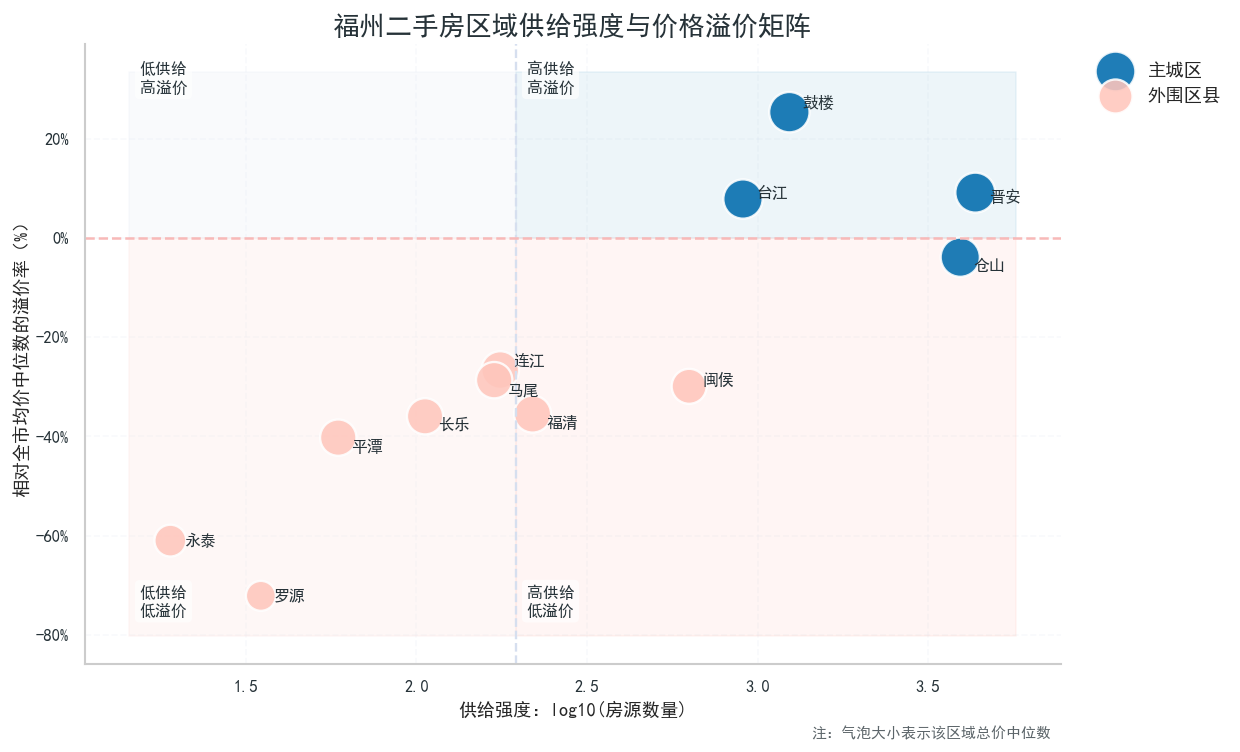

In [247]:
# 图1：区域供给强度与价格溢价矩阵

district_viz = df_price.groupby(['市区', '区域圈层']).agg(
    房源数量=('id', 'count'),
    均价中位数=('均价_元每平', 'median'),
    总价中位数=('总价_万元', 'median')
).reset_index()

# 构造矩阵分析指标
city_price_median = df_price['均价_元每平'].median()
district_viz['供给强度'] = np.log10(district_viz['房源数量'])
district_viz['均价溢价率'] = (district_viz['均价中位数'] / city_price_median - 1) * 100

# 气泡大小表示总价中位数，使用开方缩放避免过大
district_viz['气泡大小'] = np.sqrt(district_viz['总价中位数']) * 42

# 分割线：供给强度中位数 + 全市价格基准线
x_mid = district_viz['供给强度'].median()
y_mid = 0

fig, ax = plt.subplots(figsize=(10.5, 6.4))

x_min = district_viz['供给强度'].min() - 0.12
x_max = district_viz['供给强度'].max() + 0.12
y_min = district_viz['均价溢价率'].min() - 8
y_max = district_viz['均价溢价率'].max() + 8

# 背景分区，透明度降低，突出气泡
ax.fill_between([x_min, x_mid], y_mid, y_max, color=colors['cloud_blue'], alpha=0.13)
ax.fill_between([x_mid, x_max], y_mid, y_max, color=colors['ice_blue'], alpha=0.20)
ax.fill_between([x_min, x_mid], y_min, y_mid, color=colors['fog_pink'], alpha=0.32)
ax.fill_between([x_mid, x_max], y_min, y_mid, color=colors['coral_pink'], alpha=0.16)

# 绘制气泡
for layer, color in zip(['主城区', '外围区县'], [colors['deep_blue'], colors['coral_pink']]):
    temp = district_viz[district_viz['区域圈层'] == layer]
    ax.scatter(
        temp['供给强度'],
        temp['均价溢价率'],
        s=temp['气泡大小'],
        color=color,
        alpha=0.88,
        edgecolor='white',
        linewidth=1.4,
        label=layer
    )

# 四象限分割线
ax.axvline(x_mid, color=colors['cloud_blue'], linestyle='--', linewidth=1.4)
ax.axhline(y_mid, color=colors['light_pink'], linestyle='--', linewidth=1.5)

# 标签偏移，减少重叠
label_offsets = {
    '鼓楼': (8, 6),
    '晋安': (8, -2),
    '台江': (8, 4),
    '仓山': (8, -5),
    '闽侯': (8, 4),
    '连江': (8, 6),
    '马尾': (8, -6),
    '福清': (8, -5),
    '长乐': (8, -5),
    '平潭': (8, -5),
    '永泰': (8, 0),
    '罗源': (8, 0)
}

for _, row in district_viz.iterrows():
    dx, dy = label_offsets.get(row['市区'], (8, 0))
    ax.annotate(
        row['市区'],
        xy=(row['供给强度'], row['均价溢价率']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=9.5,
        color=colors['text'],
        va='center'
    )

# 四象限说明
box_style = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.65)

ax.text(x_min + 0.03, y_max - 4, '低供给\n高溢价', fontsize=9.5, color=colors['text'], bbox=box_style)
ax.text(x_mid + 0.03, y_max - 4, '高供给\n高溢价', fontsize=9.5, color=colors['text'], bbox=box_style)
ax.text(x_min + 0.03, y_min + 4, '低供给\n低溢价', fontsize=9.5, color=colors['text'], bbox=box_style)
ax.text(x_mid + 0.03, y_min + 4, '高供给\n低溢价', fontsize=9.5, color=colors['text'], bbox=box_style)

# 标题和坐标轴
ax.set_title('福州二手房区域供给强度与价格溢价矩阵', fontsize=16, fontweight='bold', color=colors['text'])
ax.set_xlabel('供给强度：log10(房源数量)', fontsize=11)
ax.set_ylabel('相对全市均价中位数的溢价率（%）', fontsize=11)

ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0f}%')

# 图例和注释
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1.0))

ax.text(
    0.99, -0.12,
    '注：气泡大小表示该区域总价中位数',
    transform=ax.transAxes,
    ha='right',
    fontsize=9,
    color=colors['text'],
    alpha=0.75
)

# 美化
ax.grid(axis='both', linestyle='--', alpha=0.16, color=colors['cloud_blue'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10, colors=colors['text'])

plt.tight_layout()
plt.show()


图表1以 `log10(房源数量)` 表示区域供给强度，以各市区均价中位数相对全市均价中位数的溢价率表示价格水平差异，气泡大小表示该区域总价中位数，颜色区分主城区和外围区县。相比单独比较房源数量或均价，该图能够同时展示区域供给规模、价格水平和圈层差异。

从图中可以看出，福州二手房市场呈现出明显的“主城区高供给、高溢价”特征。鼓楼、台江和晋安均位于价格溢价区间，其中鼓楼的价格溢价最为突出，说明其虽然房源数量不及晋安和仓山，但凭借中心区位、教育医疗资源和成熟配套，仍保持较高的单价水平。晋安则同时具备较高供给强度和较高价格溢价，是样本中兼具挂牌活跃度和价格优势的重要区域。

仓山位于高供给但低溢价区域，说明其房源数量较多，但均价中位数略低于全市中位数。该结果表明，仓山在样本中更体现出“供给活跃、价格相对平衡”的特征，可能更接近刚需和普通改善型购房需求。相比之下，罗源、永泰、平潭、长乐等外围区县集中在低溢价区间，说明其二手房价格水平明显低于主城区，区域位置和城市配套差异对房价具有较强影响。

总体来看，福州二手房市场并不是简单的“房源越多，价格越高”。鼓楼属于低供给但高溢价区域，晋安属于高供给且高溢价区域，仓山则表现为高供给但价格相对平稳。该结果说明，房价水平不仅受到房源供给规模影响，更与区域区位、资源配置、交通条件和居住成熟度密切相关。

### 图表 2：不同市区二手房均价分布差异

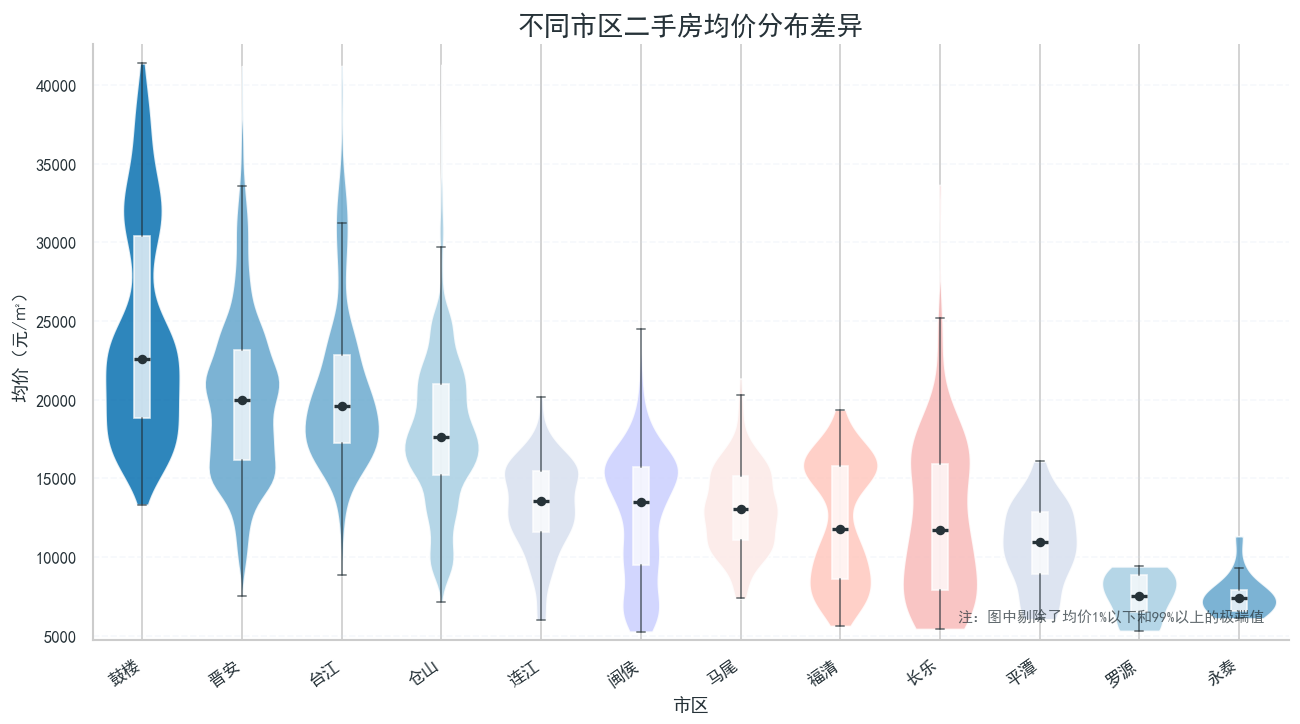

In [248]:
# 图2：不同市区二手房均价分布差异

# 剔除极端值，突出主体分布
q_low = df_price['均价_元每平'].quantile(0.01)
q_high = df_price['均价_元每平'].quantile(0.99)

violin_data = df_price[
    (df_price['均价_元每平'] >= q_low) &
    (df_price['均价_元每平'] <= q_high)
].copy()

# 按均价中位数排序
district_order = (
    violin_data.groupby('市区')['均价_元每平']
    .median()
    .sort_values(ascending=False)
    .index
)

plot_data = [
    violin_data.loc[violin_data['市区'] == d, '均价_元每平'].dropna()
    for d in district_order
]

fig, ax = plt.subplots(figsize=(11, 6.2))

# 小提琴主体
parts = ax.violinplot(
    plot_data,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    widths=0.75
)

palette = [
    colors['deep_blue'], colors['lake_blue'], colors['sea_blue'], colors['ice_blue'],
    colors['cloud_blue'], colors['lavender'], colors['fog_pink'], colors['coral_pink'],
    colors['light_pink'], colors['cloud_blue'], colors['ice_blue'], colors['lake_blue']
]

for i, body in enumerate(parts['bodies']):
    body.set_facecolor(palette[i % len(palette)])
    body.set_edgecolor('white')
    body.set_alpha(0.82)

# 叠加箱线图，突出四分位数和中位数
box = ax.boxplot(
    plot_data,
    widths=0.16,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color=colors['text'], linewidth=2),
    boxprops=dict(facecolor='white', color='white', alpha=0.75),
    whiskerprops=dict(color=colors['text'], linewidth=1.2, alpha=0.55),
    capprops=dict(color=colors['text'], linewidth=1.2, alpha=0.55)
)

# 添加中位数数值点
medians = [np.median(x) for x in plot_data]
ax.scatter(
    range(1, len(medians) + 1),
    medians,
    s=22,
    color=colors['text'],
    zorder=3
)

ax.set_xticks(range(1, len(district_order) + 1))
ax.set_xticklabels(district_order, rotation=35, ha='right')

ax.set_title('不同市区二手房均价分布差异', fontsize=16, fontweight='bold', color=colors['text'])
ax.set_xlabel('市区', fontsize=11)
ax.set_ylabel('均价（元/㎡）', fontsize=11)

# 限制y轴范围，突出主体分布
ax.set_ylim(q_low * 0.9, q_high * 1.03)

# 注释放到图内右下角，避免被截断
ax.text(
    0.98, 0.03,
    '注：图中剔除了均价1%以下和99%以上的极端值',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    color=colors['text'],
    alpha=0.72
)

clean_axis(ax)
plt.tight_layout()
plt.show()

图表2展示了不同市区二手房均价的分布情况。为避免少量极端高价或低价房源影响图形可读性，图中剔除了均价 1% 以下和 99% 以上的极端值。

从图中可以看出，鼓楼的均价分布整体处于最高水平，中位数明显高于其他区域，且上侧分布较长，说明鼓楼不仅整体价格高，也存在较多高单价房源。晋安、台江和仓山的均价中位数也处于较高区间，构成福州二手房价格的主城区梯队。

外围区县的均价分布整体明显下移，其中罗源、永泰等区域处于最低水平。与此同时，长乐、闽侯、福清等区域的分布跨度相对较大，说明外围区域内部也存在一定价格分层。整体来看，福州二手房价格呈现出明显的主城区高、外围区县低的空间差异。

### 图表 3：面积与总价关系：主城区与外围区县对比

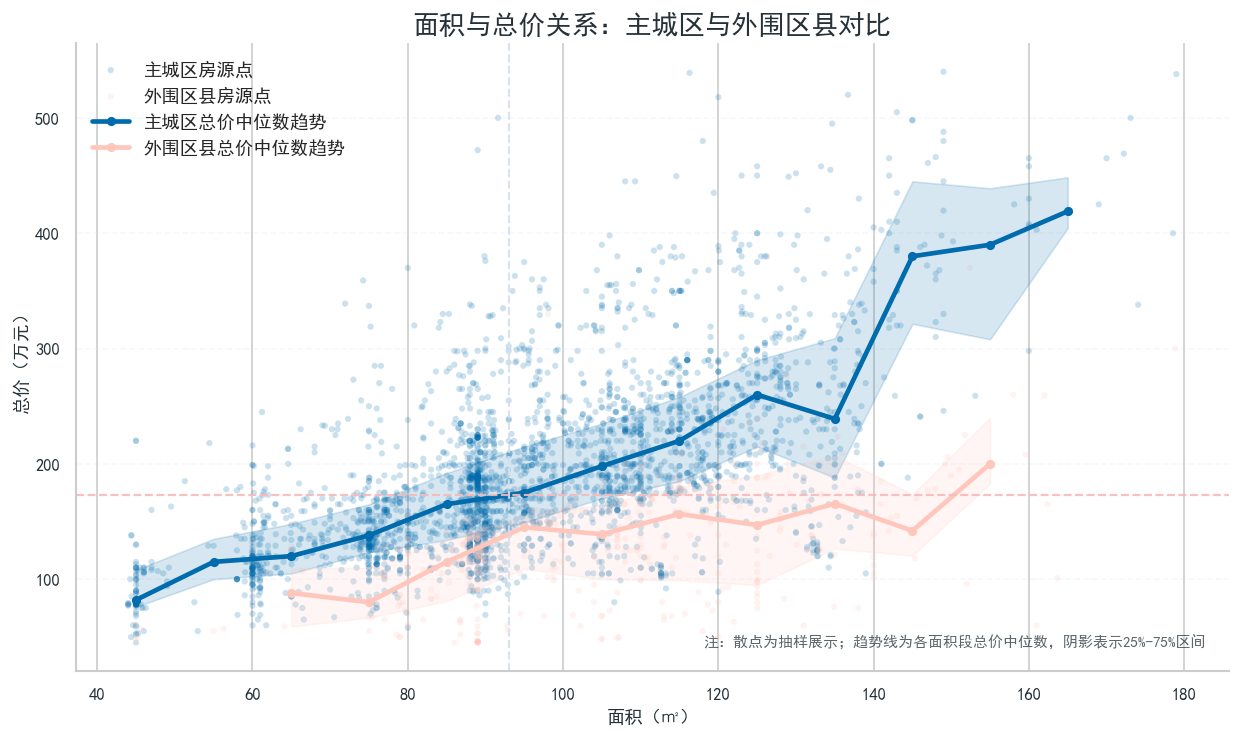

In [249]:
# 图3：面积与总价关系：主城区与外围区县对比

# 过滤极端值，提升主体分布可读性
plot_df = df_price[
    (df_price['面积_㎡'] >= df_price['面积_㎡'].quantile(0.01)) &
    (df_price['面积_㎡'] <= df_price['面积_㎡'].quantile(0.99)) &
    (df_price['总价_万元'] >= df_price['总价_万元'].quantile(0.01)) &
    (df_price['总价_万元'] <= df_price['总价_万元'].quantile(0.99))
].copy()

# 按面积分箱，用于计算不同面积段的价格趋势
bins = np.arange(20, 190, 10)
plot_df['面积分箱'] = pd.cut(plot_df['面积_㎡'], bins=bins, right=False)
plot_df['面积中点'] = plot_df['面积分箱'].apply(lambda x: x.mid if pd.notna(x) else np.nan)

trend = plot_df.groupby(['区域圈层', '面积中点'], observed=True).agg(
    房源数量=('id', 'count'),
    总价中位数=('总价_万元', 'median'),
    总价下四分位=('总价_万元', lambda x: x.quantile(0.25)),
    总价上四分位=('总价_万元', lambda x: x.quantile(0.75))
).reset_index()

# 只保留样本量较充足的面积段，避免少量样本造成趋势波动
trend = trend[trend['房源数量'] >= 20]

fig, ax = plt.subplots(figsize=(10.5, 6.3))

# 为避免散点过密，抽样展示背景点
scatter_sample = plot_df.sample(
    n=min(3500, len(plot_df)),
    random_state=42
)

for layer, color in zip(['主城区', '外围区县'], [colors['deep_blue'], colors['coral_pink']]):
    temp = scatter_sample[scatter_sample['区域圈层'] == layer]
    ax.scatter(
        temp['面积_㎡'],
        temp['总价_万元'],
        s=14,
        alpha=0.20,
        color=color,
        edgecolor='none',
        label=f'{layer}房源点'
    )

# 绘制趋势线和四分位区间
for layer, color in zip(['主城区', '外围区县'], [colors['deep_blue'], colors['coral_pink']]):
    temp = trend[trend['区域圈层'] == layer].sort_values('面积中点')
    
    ax.fill_between(
        temp['面积中点'].astype(float),
        temp['总价下四分位'].astype(float),
        temp['总价上四分位'].astype(float),
        color=color,
        alpha=0.16
    )
    
    ax.plot(
        temp['面积中点'],
        temp['总价中位数'],
        color=color,
        linewidth=2.8,
        marker='o',
        markersize=4.5,
        label=f'{layer}总价中位数趋势'
    )

# 添加整体中位数参考线
ax.axvline(
    plot_df['面积_㎡'].median(),
    color=colors['cloud_blue'],
    linestyle='--',
    linewidth=1.3,
    alpha=0.9
)

ax.axhline(
    plot_df['总价_万元'].median(),
    color=colors['light_pink'],
    linestyle='--',
    linewidth=1.3,
    alpha=0.9
)

ax.text(
    0.98, 0.04,
    '注：散点为抽样展示；趋势线为各面积段总价中位数，阴影表示25%-75%区间',
    transform=ax.transAxes,
    ha='right',
    fontsize=9,
    color=colors['text'],
    alpha=0.75
)

ax.set_title('面积与总价关系：主城区与外围区县对比', fontsize=16, fontweight='bold', color=colors['text'])
ax.set_xlabel('面积（㎡）', fontsize=11)
ax.set_ylabel('总价（万元）', fontsize=11)

ax.legend(frameon=False, loc='upper left')
clean_axis(ax)

plt.tight_layout()
plt.show()

图表3展示了房源面积与总价之间的关系。图中散点为房源样本点，趋势线表示不同面积段的总价中位数，阴影区域表示各面积段总价的 25%—75% 区间。

从整体趋势看，面积与总价呈明显正相关关系，说明房屋面积仍然是影响总价的重要因素。随着面积增加，主城区和外围区县的总价中位数整体均呈上升趋势。

进一步比较可以发现，在相近面积段下，主城区总价中位数普遍高于外围区县，尤其在 90㎡以上面积段差异更明显。这说明总价不仅由面积决定，区域位置也会显著影响房源价格。主城区由于区位、交通、配套和资源优势，即使在相同面积条件下，也往往具有更高的价格水平。

此外，120㎡以上房源的价格波动明显扩大，说明改善型和大面积房源内部差异更强，可能受到小区品质、板块位置和房屋类型等因素影响。

### 图表 4：不同市区与户型类别的均价气泡矩阵

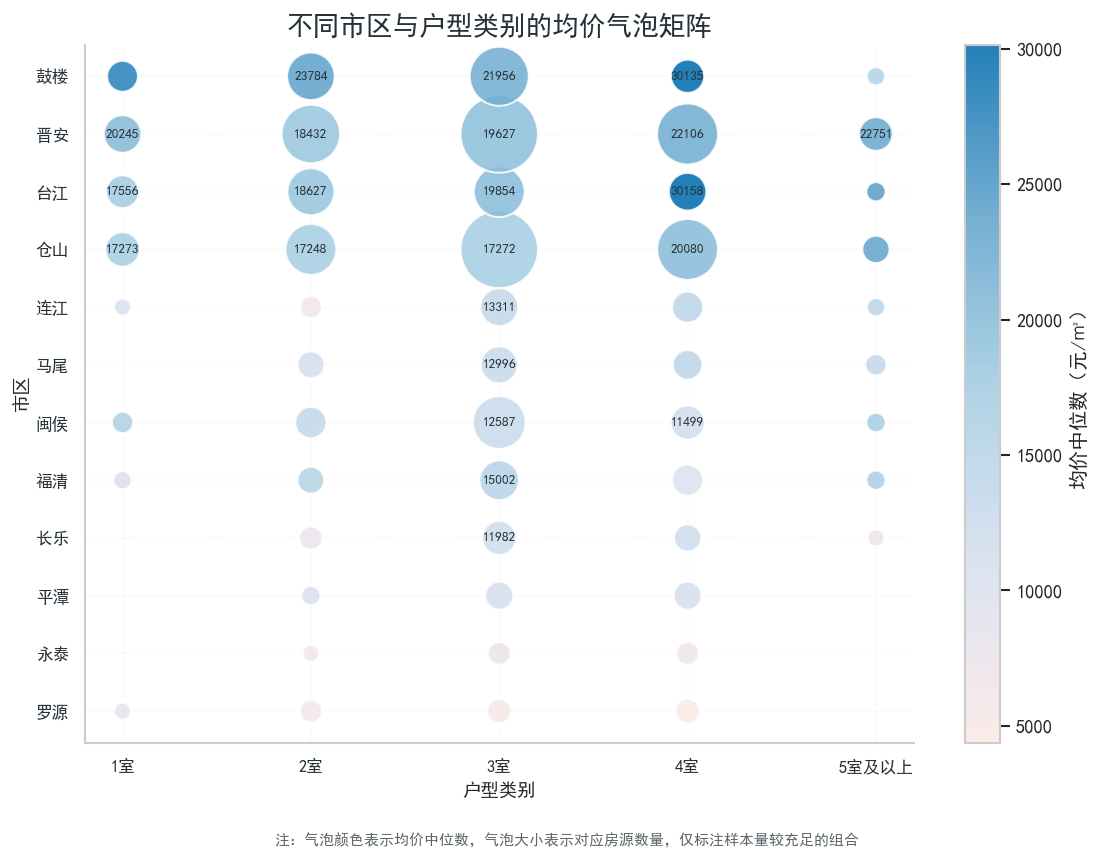

In [250]:
# 图4：不同市区与户型类别的均价气泡矩阵

room_order = ['1室', '2室', '3室', '4室', '5室及以上']

bubble_data = df_price.groupby(['市区', '户型类别']).agg(
    房源数量=('id', 'count'),
    均价中位数=('均价_元每平', 'median')
).reset_index()

# 按市区整体均价中位数排序，高价区域排在上方
district_order = (
    df_price.groupby('市区')['均价_元每平']
    .median()
    .sort_values(ascending=False)
    .index
)

bubble_data['市区'] = pd.Categorical(bubble_data['市区'], categories=district_order, ordered=True)
bubble_data['户型类别'] = pd.Categorical(bubble_data['户型类别'], categories=room_order, ordered=True)
bubble_data = bubble_data.dropna(subset=['市区', '户型类别'])

x_map = {room: i for i, room in enumerate(room_order)}
y_map = {district: i for i, district in enumerate(district_order)}

bubble_data['x'] = bubble_data['户型类别'].map(x_map)
bubble_data['y'] = bubble_data['市区'].map(y_map)

# 缩放气泡大小，避免主流户型气泡过大
max_count = bubble_data['房源数量'].max()
bubble_data['size'] = 60 + (np.sqrt(bubble_data['房源数量']) / np.sqrt(max_count)) * 2100

fig, ax = plt.subplots(figsize=(9.6, 7.2))

sc = ax.scatter(
    bubble_data['x'],
    bubble_data['y'],
    s=bubble_data['size'],
    c=bubble_data['均价中位数'],
    cmap=blue_cmap,
    alpha=0.86,
    edgecolor='white',
    linewidth=1.2
)

# 只标注样本较充足的组合，避免画面过密
for _, row in bubble_data.iterrows():
    if row['房源数量'] >= 50:
        ax.text(
            row['x'],
            row['y'],
            f"{row['均价中位数']:.0f}",
            ha='center',
            va='center',
            fontsize=8,
            color=colors['text']
        )

ax.set_xticks(range(len(room_order)))
ax.set_xticklabels(room_order)
ax.set_yticks(range(len(district_order)))
ax.set_yticklabels(district_order)

# 让高价区域出现在图上方
ax.invert_yaxis()

ax.set_title('不同市区与户型类别的均价气泡矩阵', fontsize=16, fontweight='bold', color=colors['text'])
ax.set_xlabel('户型类别', fontsize=11)
ax.set_ylabel('市区', fontsize=11)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('均价中位数（元/㎡）')

# 图下注释放到更低位置，避免与横轴标题重叠
fig.text(
    0.5, 0.01,
    '注：气泡颜色表示均价中位数，气泡大小表示对应房源数量，仅标注样本量较充足的组合',
    ha='center',
    fontsize=9,
    color=colors['text'],
    alpha=0.75
)

plt.subplots_adjust(bottom=0.16)

ax.grid(axis='both', linestyle='--', alpha=0.16, color=colors['cloud_blue'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10, colors=colors['text'])

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

图表4从“市区 × 户型类别”两个维度展示二手房均价差异。其中，气泡颜色表示均价中位数，颜色越深代表单价越高；气泡大小表示对应房源数量，气泡越大说明该组合下挂牌房源越多。

从图中可以看出，鼓楼、晋安、台江和仓山在多数户型类别中均价水平较高，尤其是鼓楼和台江的4室房源均价中位数超过 30000 元/㎡，说明核心城区的大户型房源具有明显价格优势。晋安和仓山虽然均价略低于鼓楼、台江，但3室和4室房源气泡较大，说明这两个区域是家庭型和改善型房源的重要供给区域。

从户型结构看，3室房源在晋安、仓山、鼓楼、台江等区域的气泡明显较大，说明3室是福州二手房市场中的主力户型。4室房源在主城区中也表现出较高均价，反映出改善型需求在核心区域具有更高价格承载力。

外围区县整体颜色较浅，说明其各类户型均价普遍低于主城区。总体来看，福州二手房价格不仅存在区域差异，也存在户型差异；核心城区的大户型和改善型房源更容易形成高单价，而晋安、仓山的3室房源则体现出较强的市场供给特征。

### 图表5：不同面积段内部的总价结构分布

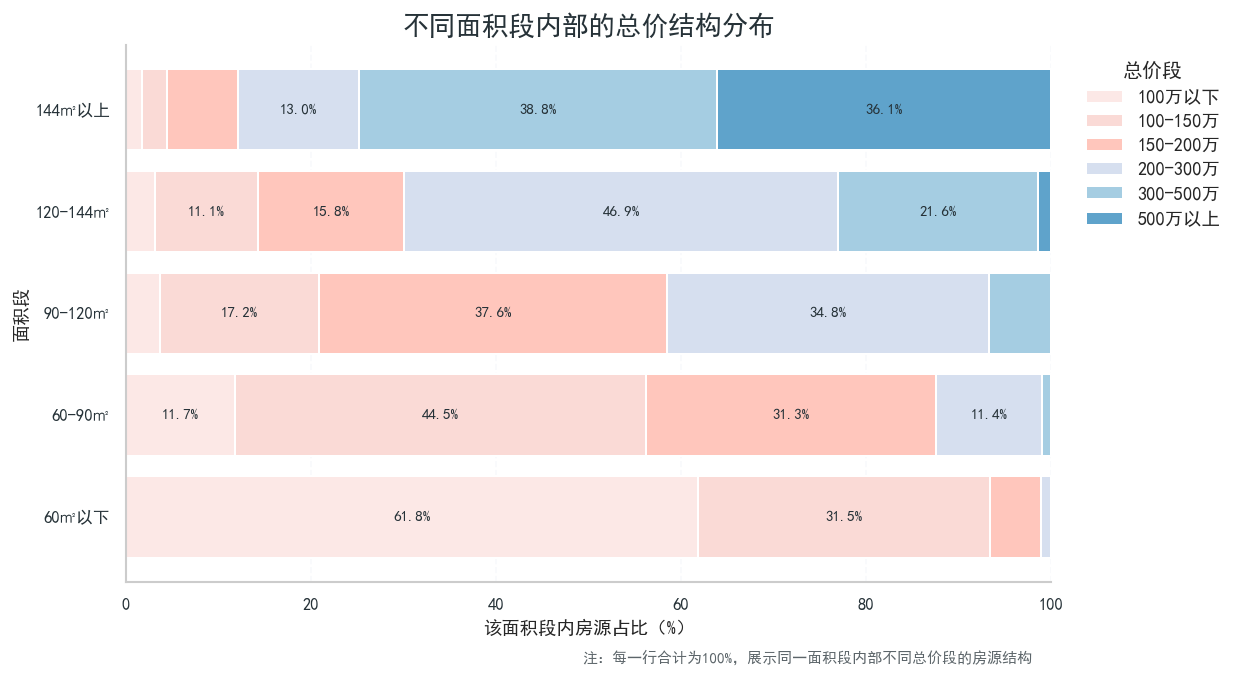

In [251]:
# 图5：不同面积段内部的总价结构分布

structure_table = pd.crosstab(
    df_price['面积段'],
    df_price['总价段']
)

structure_rate = structure_table.div(structure_table.sum(axis=1), axis=0) * 100

area_order = ['60㎡以下', '60-90㎡', '90-120㎡', '120-144㎡', '144㎡以上']
price_order = ['100万以下', '100-150万', '150-200万', '200-300万', '300-500万', '500万以上']

structure_rate = structure_rate.reindex(area_order)[price_order]

stack_colors = [
    "#FCE8E6",  # 100万以下
    "#FADAD6",  # 100-150万
    "#FFC6BC",  # 150-200万
    "#D6DFEF",  # 200-300万
    "#A5CDE2",  # 300-500万
    "#5FA3CB"   # 500万以上
]

fig, ax = plt.subplots(figsize=(10.5, 5.8))

left = np.zeros(len(structure_rate))

for i, price_band in enumerate(price_order):
    values = structure_rate[price_band].fillna(0).values
    
    ax.barh(
        structure_rate.index,
        values,
        left=left,
        color=stack_colors[i],
        edgecolor='white',
        linewidth=1.2,
        label=price_band
    )
    
    # 只标注占比较高的部分，避免文字拥挤
    for y_idx, value in enumerate(values):
        if value >= 10:
            ax.text(
                left[y_idx] + value / 2,
                y_idx,
                f'{value:.1f}%',
                ha='center',
                va='center',
                fontsize=9,
                color=colors['text']
            )
    
    left += values

ax.set_title('不同面积段内部的总价结构分布', fontsize=16, fontweight='bold', color=colors['text'])
ax.set_xlabel('该面积段内房源占比（%）', fontsize=11)
ax.set_ylabel('面积段', fontsize=11)

ax.set_xlim(0, 100)

ax.legend(
    title='总价段',
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.text(
    0.98, -0.15,
    '注：每一行合计为100%，展示同一面积段内部不同总价段的房源结构',
    transform=ax.transAxes,
    ha='right',
    fontsize=9,
    color=colors['text'],
    alpha=0.75
)

ax.grid(axis='x', linestyle='--', alpha=0.16, color=colors['cloud_blue'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10, colors=colors['text'])

plt.tight_layout()
plt.show()

图表5展示了不同面积段房源内部的总价结构。由于每一行均按 100% 进行标准化，因此该图可以直接比较不同面积段对应的价格组成差异。

从图中可以看出，房源总价结构随面积段提升呈现明显上移趋势。60㎡以下房源主要集中在100万元以下和100—150万元区间，说明小面积房源整体购房门槛较低，更偏向刚需或过渡型需求。60—90㎡房源则主要集中在100—200万元区间，是较典型的刚需型产品。

90—120㎡和120—144㎡房源的总价结构明显向中高价段移动，其中90—120㎡房源以150—300万元为主，120—144㎡房源则以200—500万元为主，说明中等面积和改善型房源已经成为总价提升的重要分界。144㎡以上房源中，300万元以上占比较高，且500万元以上房源占比明显增加，体现出大面积房源更偏向改善型和高端居住需求。

整体来看，面积段与总价段之间存在清晰的梯度关系：面积越大，房源越容易进入高总价区间。该结果说明面积是影响二手房总价结构的重要因素，但不同面积段内部仍存在一定价格分化，后续还需要结合区域、板块和房源品质进一步解释。

### 图表6：高价板块TOP15：相对全市均价中位数的溢价率

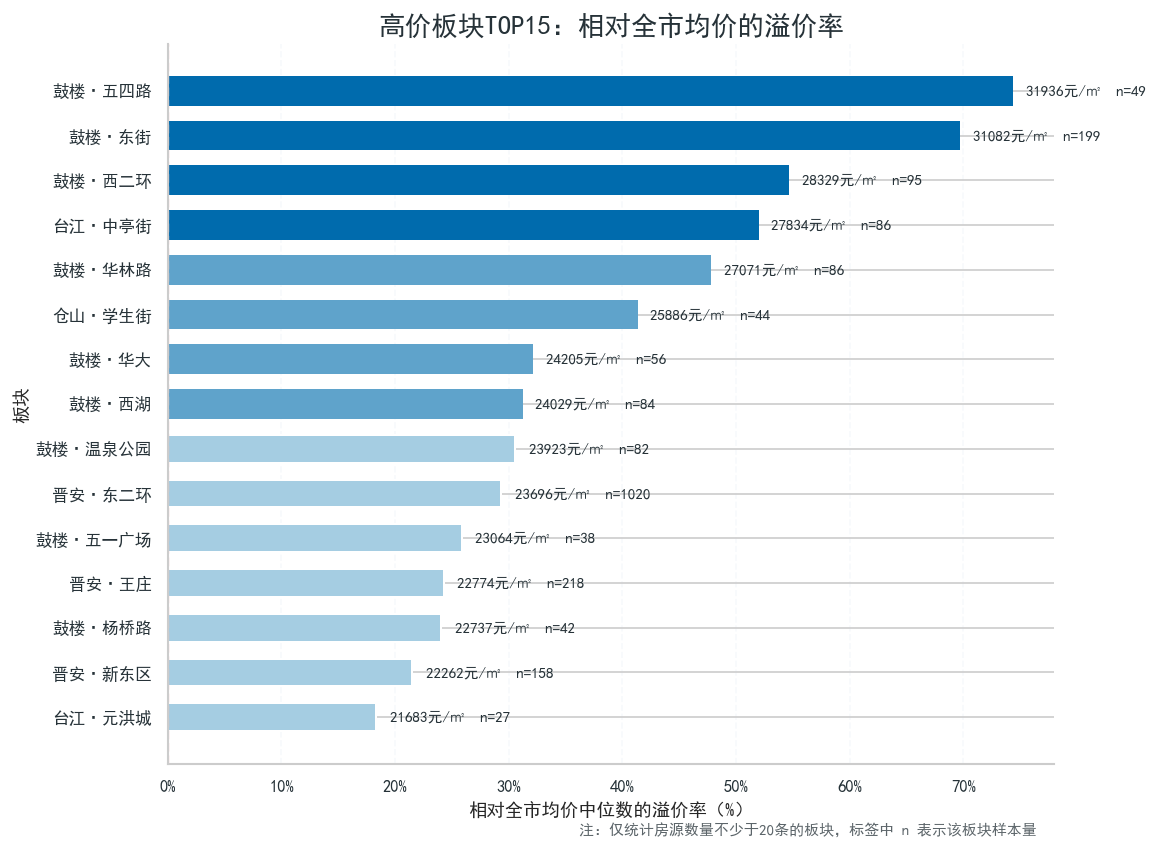

In [252]:
# 图6：高价板块TOP15：相对全市均价中位数的溢价率

# 按“市区 + 板块”统计，避免使用过细的具体地址
block_stats = df_price.groupby(['市区', '板块']).agg(
    房源数量=('id', 'count'),
    均价中位数=('均价_元每平', 'median'),
    总价中位数=('总价_万元', 'median')
).reset_index()

# 设置样本门槛，避免样本过少导致价格失真
block_stats = block_stats[block_stats['房源数量'] >= 20].copy()

# 计算相对全市均价中位数的溢价率
city_median_price = df_price['均价_元每平'].median()
block_stats['溢价率'] = (block_stats['均价中位数'] / city_median_price - 1) * 100
block_stats['板块标签'] = block_stats['市区'] + '·' + block_stats['板块']

# 取高价板块TOP15
block_top = (
    block_stats
    .sort_values('均价中位数', ascending=False)
    .head(15)
    .sort_values('均价中位数', ascending=True)
)

fig, ax = plt.subplots(figsize=(9.8, 7.2))

y_pos = np.arange(len(block_top))

# 横向条形图：长度表示溢价率
bars = ax.barh(
    y_pos,
    block_top['溢价率'],
    color=colors['ice_blue'],
    edgecolor='white',
    linewidth=1.2,
    height=0.62
)

# 突出最高的几个板块
for i, bar in enumerate(bars):
    if block_top['溢价率'].iloc[i] >= block_top['溢价率'].quantile(0.75):
        bar.set_color(colors['deep_blue'])
    elif block_top['溢价率'].iloc[i] >= block_top['溢价率'].median():
        bar.set_color(colors['lake_blue'])

# 添加数值标签：均价中位数 + 样本量
for i, row in block_top.iterrows():
    y = list(block_top.index).index(i)
    ax.text(
        row['溢价率'] + 1.2,
        y,
        f"{row['均价中位数']:.0f}元/㎡  n={row['房源数量']}",
        va='center',
        ha='left',
        fontsize=9,
        color=colors['text']
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(block_top['板块标签'])

ax.axvline(
    0,
    color=colors['light_pink'],
    linestyle='--',
    linewidth=1.4,
    alpha=0.9
)

ax.set_title('高价板块TOP15：相对全市均价的溢价率', fontsize=16, fontweight='bold', color=colors['text'])
ax.set_xlabel('相对全市均价中位数的溢价率（%）', fontsize=11)
ax.set_ylabel('板块', fontsize=11)

ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0f}%')

ax.text(
    0.98, -0.10,
    '注：仅统计房源数量不少于20条的板块，标签中 n 表示该板块样本量',
    transform=ax.transAxes,
    ha='right',
    fontsize=9,
    color=colors['text'],
    alpha=0.75
)

ax.grid(axis='x', linestyle='--', alpha=0.18, color=colors['cloud_blue'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10, colors=colors['text'])

plt.tight_layout()
plt.show()

图表6选取房源数量不少于20条的板块，计算其均价中位数相对全市均价中位数的溢价率，用于识别福州二手房市场中的高价板块。

从结果看，高价板块明显集中在鼓楼、台江、晋安和仓山等主城区。其中，鼓楼五四路、鼓楼东街、鼓楼西二环等板块溢价率较高，均价中位数均明显高于全市整体水平，说明鼓楼核心板块仍是福州二手房市场中价格最突出的区域。

值得注意的是，晋安东二环板块虽然均价中位数不是最高，但样本量达到 1020 条，说明该板块不仅价格水平较高，而且房源供给规模较大，具有较强的市场代表性。相比之下，部分高价板块虽然溢价率更高，但样本量相对较小，结论需要结合房源数量谨慎理解。

整体来看，福州高价二手房板块主要集中在中心城区和成熟配套区域。这进一步说明，房价差异不仅体现在市区层面，在同一市区内部也存在明显的板块分化。

### 图表7：不同房龄下主城区与外围区县均价差异

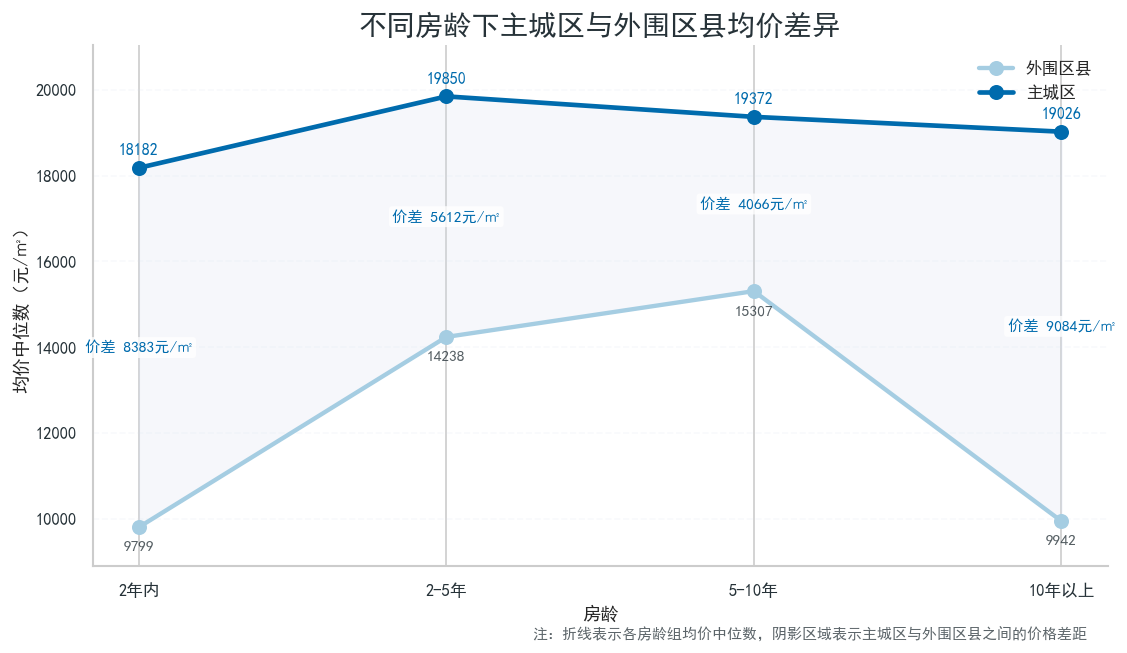

In [253]:
# 图7：不同房龄下主城区与外围区县均价差异

age_order = ['2年内', '2-5年', '5-10年', '10年以上']

age_circle = df_price.pivot_table(
    index='房龄',
    columns='区域圈层',
    values='均价_元每平',
    aggfunc='median'
).reindex(age_order)

age_circle['价差'] = age_circle['主城区'] - age_circle['外围区县']

x = np.arange(len(age_circle.index))

fig, ax = plt.subplots(figsize=(9.6, 5.6))

# 颜色
main_color = colors['deep_blue']     # 主城区
outer_color = colors['ice_blue']     # 外围区县
fill_color = colors['cloud_blue']    # 阴影
text_color = colors['text']

# 阴影区：价差
ax.fill_between(
    x,
    age_circle['外围区县'],
    age_circle['主城区'],
    color=fill_color,
    alpha=0.22,
    zorder=1
)

# 外围区县折线
ax.plot(
    x,
    age_circle['外围区县'],
    marker='o',
    markersize=8,
    linewidth=2.6,
    color=outer_color,
    label='外围区县',
    zorder=3
)

# 主城区折线
ax.plot(
    x,
    age_circle['主城区'],
    marker='o',
    markersize=8,
    linewidth=2.8,
    color=main_color,
    label='主城区',
    zorder=4
)

# 标注数值：主城区在上，外围区县在下
for i, row in enumerate(age_circle.itertuples()):
    main_val = getattr(row, '主城区')
    outer_val = getattr(row, '外围区县')
    gap_val = getattr(row, '价差')

    # 主城区标签
    ax.text(
        i,
        main_val + 260,
        f'{main_val:.0f}',
        ha='center',
        va='bottom',
        fontsize=9.5,
        color=main_color,
        fontweight='bold'
    )

    # 外围区县标签
    ax.text(
        i,
        outer_val - 320,
        f'{outer_val:.0f}',
        ha='center',
        va='top',
        fontsize=9.2,
        color=text_color,
        alpha=0.78
    )

    # 中间写价差
    ax.text(
        i,
        (main_val + outer_val) / 2,
        f'价差 {gap_val:.0f}元/㎡',
        ha='center',
        va='center',
        fontsize=9.2,
        color=main_color,
        bbox=dict(
            boxstyle='round,pad=0.22',
            fc='white',
            ec='none',
            alpha=0.78
        )
    )

# 坐标轴
ax.set_xticks(x)
ax.set_xticklabels(age_circle.index)

ax.set_title('不同房龄下主城区与外围区县均价差异', fontsize=17, fontweight='bold', color=text_color)
ax.set_xlabel('房龄', fontsize=11)
ax.set_ylabel('均价中位数（元/㎡）', fontsize=11)

# 控制纵轴范围，减少留白
y_min = age_circle[['主城区', '外围区县']].min().min() - 900
y_max = age_circle[['主城区', '外围区县']].max().max() + 1200
ax.set_ylim(y_min, y_max)

# 图例放右上，避免压标题
ax.legend(
    frameon=False,
    loc='upper right',
    fontsize=10
)

# 注释
ax.text(
    0.98, -0.14,
    '注：折线表示各房龄组均价中位数，阴影区域表示主城区与外围区县之间的价格差距',
    transform=ax.transAxes,
    ha='right',
    fontsize=9,
    color=text_color,
    alpha=0.75
)

# 美化
ax.grid(axis='y', linestyle='--', alpha=0.16, color=colors['cloud_blue'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10, colors=text_color)

plt.tight_layout()
plt.show()

图表7对比了不同房龄条件下主城区与外围区县的均价中位数。折线表示各房龄组的价格水平，阴影区域表示主城区与外围区县之间的价格差距。

从图中可以看出，在所有房龄组中，主城区均价中位数均高于外围区县，说明区域圈层差异对房价具有持续影响。即使在相同房龄条件下，主城区仍然保持更高价格水平，表明区位、交通、配套和公共资源对二手房价格具有明显支撑作用。

从房龄变化看，主城区不同房龄房源的均价整体较稳定，主要集中在 18000—20000 元/㎡之间；外围区县波动更明显，其中 5—10 年房源均价较高，而 2 年内和 10 年以上房源价格相对较低。两类区域的价差在 10 年以上房源中最大，达到 9084 元/㎡，说明老房源价格并不完全由房龄决定，核心区位仍可能显著提升房屋价值。

总体来看，房龄会影响二手房价格，但区域位置的影响更为稳定和显著。对于福州二手房市场而言，主城区的区位优势能够在不同房龄阶段持续体现。

## 8. 主要结论

通过对福州二手房挂牌数据进行清洗、统计分析和可视化展示，本文得到以下主要结论。

第一，福州二手房市场呈现出“核心溢价型、供给主力型、外围低价型”的分层结构，而不是简单的区域价格排序。统计结果显示，晋安和仓山是样本中房源数量最多的两个区域，在价格有效样本中分别有 4346 条和 3926 条房源；但从价格水平看，鼓楼的均价中位数最高，达到 22973 元/㎡。区域供给强度与价格溢价矩阵进一步表明，鼓楼属于低供给但高溢价区域，说明其价格优势主要来自中心区位和资源稀缺性；晋安属于高供给且高溢价区域，体现出挂牌活跃度和价格水平同时较强；仓山则属于高供给但价格相对平稳的区域，更接近刚需和普通改善型市场。由此可见，福州二手房市场不能只用“中心贵、外围便宜”来概括，不同主城区内部也存在不同的市场角色。

第二，主城区与外围区县的价格差异具有稳定性，区位因素比房龄更能解释价格分层。主城区均价中位数为 19293 元/㎡，明显高于外围区县的 12297 元/㎡；主城区总价中位数为 180 万元，也高于外围区县的 123 万元。不同房龄下的价格对比进一步显示，在所有房龄组中，主城区均价中位数均高于外围区县，其中10年以上房源的价差达到 9084 元/㎡。这说明房龄并不是单独决定房价的因素，核心区位带来的资源和配套优势能够在不同房龄阶段持续影响房屋价值。换言之，部分老房源如果位于核心城区，仍可能具有较高价格支撑。

第三，面积主要决定总价水平，但不足以解释单价差异。相关性分析显示，面积与总价的相关系数为 0.643，说明面积扩大通常会推动总价上升；但面积与均价的相关系数仅为 0.143，说明单位面积价格并不主要由面积决定。面积与总价趋势图也显示，在相近面积段下，主城区总价中位数普遍高于外围区县，尤其在90㎡以上面积段差异更加明显。因此，面积更像是总价的基础变量，而区域位置、板块资源、小区品质和配套条件才是解释均价差异的重要因素。

第四，福州二手房的主力产品集中在家庭型和普通改善型需求，但不同面积段对应的购房门槛明显分化。户型统计结果显示，3室房源数量最多，共 7183 条，是样本中的绝对主力户型；4室和2室房源数量也较多，说明市场供给主要面向家庭居住和改善型需求。从面积段与总价段结构看，60㎡以下房源主要集中在低总价区间，60—90㎡房源主要集中在100—200万元区间，90—120㎡房源开始向150—300万元区间集中，120㎡以上房源则明显进入更高总价段。也就是说，面积段提升并不只是“房子变大”，同时也意味着购房门槛和产品属性从刚需逐步转向改善。

第五，高价板块主要集中在主城区内部，说明房价分化已经从“市区差异”进一步下沉到“板块差异”。在房源数量不少于20条的板块中，鼓楼五四路、鼓楼东街、鼓楼西二环、台江中亭街等板块相对全市均价中位数具有明显溢价，体现出成熟配套、核心区位和资源集聚对价格的支撑作用。与此同时，晋安东二环板块样本量达到 1020 条，虽然不是均价最高板块，但兼具较高价格和较大供给规模，具有较强市场代表性。这说明判断福州二手房价格时，不能只停留在“哪个市区更贵”，还需要进一步下钻到板块层面。

需要说明的是，本报告使用的是平台挂牌房源数据，反映的是挂牌价而非最终成交价，因此结论更适合解释样本中的挂牌市场特征，不能完全等同于真实成交市场。部分高端房源、别墅或核心地段房源会形成极端值，可能影响均值判断，因此本文在区域、户型和板块比较中更多使用中位数。对于样本量较少的板块或户型组合，其价格表现也需要谨慎解释。总体而言，本报告的分析结果表明，福州二手房价格由面积、区域、板块和产品结构共同作用形成，其中区域区位和板块资源对均价的解释力尤为突出。